# Machine Forgetters CS5841 Final Project Code File
Connor Donahue, Connor Fleser, Jessica Feliz Garrido, and Matthew Harrelson

## **Imports**: import packages used in the notebook

In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import random
import gc

2026-03-17 00:30:52.542450: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-17 00:30:52.813639: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-17 00:30:52.813695: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-17 00:30:52.821259: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-17 00:30:52.860108: I tensorflow/core/platform/cpu_feature_guar

## **Load Data**: load data used to construct model

In [2]:
# read in feature data from two csv files
df1 = pd.read_csv("pure_spectra_matrix.csv", sep=";", header = None, decimal =".")
df2 = pd.read_csv("mixed_spectra_matrix.csv", sep=";", header = None, decimal =".")

# read in label data from label files
labels1 = pd.read_csv("pure_spectra_metadata.csv", sep=";")["Species"]

# for second pair of feature and label file, pure spectra must be separated from mixed spectra 
temp_labels2 =  pd.read_csv("mixed_spectra_metadata.csv", sep=";")
labels2 = temp_labels2[(temp_labels2['Proportion'] == 0) | (temp_labels2['Proportion'] == 1)]  
df2 = df2[(temp_labels2['Proportion'] == 0) | (temp_labels2['Proportion'] == 1)]

# store labels for pure spectra
species = []
for i in range(labels2.shape[0]):
    if (labels2['Proportion'].iloc[i] == 0):
        species.append(labels2["Species_2"].iloc[i])
    else: 
        species.append(labels2["Species_1"].iloc[i])

labels2 = pd.Series(species)

# combine two data sets into one dataframe
df = pd.concat([df1, df2])
labels = pd.concat([labels1, labels2])

# visualize first few entries in the dataframe
df.head()

,0,1,2,3,4,5,6,7,8,9,...,1290,1291,1292,1293,1294,1295,1296,1297,1298,1299
0,0,0.0,0.0,0.0,0.0,0,44431.921875,0.0,0.0,0.0,...,0.000000,0.0,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0,0.0,0.0,0.0,0.0,0,0.000000,0.0,0.0,0.0,...,27667.777344,0.0,0,0.0,35438.351562,0.0,0.0,0.0,0.0,0.0
2,0,0.0,0.0,0.0,0.0,0,0.000000,0.0,0.0,0.0,...,59820.968750,0.0,0,0.0,6384.590820,0.0,0.0,0.0,0.0,0.0
3,0,0.0,0.0,0.0,0.0,0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,0,0.0,0.0,0.0,0.0,0,4701.712402,0.0,0.0,0.0,...,3913.969727,0.0,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


## **Preprocessing and Splitting Data**

### Global Variables and Random Seeds

In [3]:
BATCH = 32
EPOCHS = 50
HE = tf.keras.initializers.HeNormal(seed=42)
random.seed(42)
tf.random.set_seed(42)

### Training and Testing Spit

In [4]:
# training and testing split (10% test, 10% validation, 80% training)
X_trainval, X_test, y_trainval, y_test = train_test_split(df, labels, test_size = 0.1, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.11, stratify = y_trainval)

# encode categorical labels  
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

num_classes = len(labels.unique())

# display dimensions of training, validation, and test data
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(520, 1300)
(65, 1300)
(66, 1300)


### Preprocessing and Batching

2026-03-17 00:30:58.549771: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-17 00:30:58.845823: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-17 00:30:58.845882: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-17 00:30:58.890758: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-17 00:30:58.890809: I external/local_xla/xla/stream_executor

(32, 1300, 1) (32,)
range: tf.Tensor(0.0, shape=(), dtype=float64) - tf.Tensor(17.265071441359815, shape=(), dtype=float64)


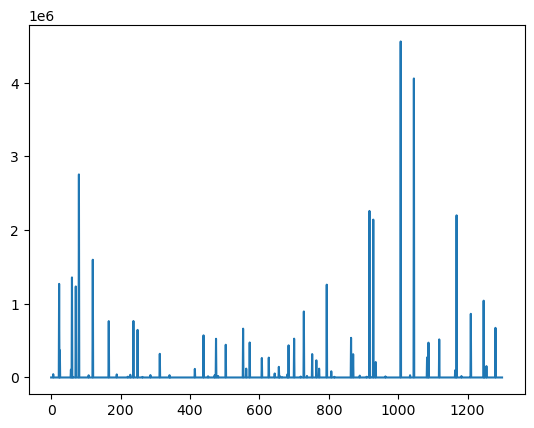

In [5]:
# define helper functions for preprocessing data

def preprocess(x, y):
  x = tf.math.log1p(x)
  x = tf.expand_dims(x, axis=-1)
  return x, y

def getTrainData():
  return tf.data.Dataset.from_tensor_slices((X_train, y_train)).map(preprocess,BATCH).shuffle(buffer_size=64).batch(BATCH).prefetch(tf.data.AUTOTUNE)

def getValData():
  return tf.data.Dataset.from_tensor_slices((X_val, y_val)).map(preprocess,BATCH).batch(BATCH).prefetch(tf.data.AUTOTUNE)

def getTestData():
  return tf.data.Dataset.from_tensor_slices((X_test, y_test)).map(preprocess,BATCH).batch(BATCH).prefetch(tf.data.AUTOTUNE)

img, label = next(iter(getTrainData()))
print(img.shape, label.shape)
print("range: " + str(tf.reduce_min(img)) + " - " + str(tf.reduce_max(img)))


plt.plot(df.iloc[0])
plt.show()


## Set up Model Compliation and Fitting

In [6]:
    
def create_callbacks():
    callback = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,         
        verbose=1,          
        restore_best_weights=True 
    )

    return callback


def compile_fit_model(model):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    
    hist = model.fit(
        getTrainData(),
        validation_data = getTestData(),
        epochs = EPOCHS,
        callbacks = create_callbacks(),
        verbose = 0
    )

    return max(hist.history["val_accuracy"])
    

## Model Construction

### Model 1: Feed-Forward Neural Network

In [7]:
def build_ffn(layers_arch, act_func):
    # input layer with batch normalization
    inputs = layers.Input(shape=(X_train.shape[1],))
    x = layers.BatchNormalization()(inputs)
    
    for layer_size in layers_arch:
        x = layers.Dense(layer_size, activation=act_func, kernel_initializer=HE)(x)
        x = layers.Dropout(0.2)(x)
        x = layers.BatchNormalization()(x)
    
    # softmax output layer
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    # Create model
    ffn = tf.keras.Model(inputs=inputs, outputs=outputs, name="basicFeedforward")

    return ffn

### Model 2: 1-Dimensional Convolutional Neural Network

In [8]:
def build_cnn(layers_arch, act_func):
    # input layer with batch normalization
    inputs = layers.Input(shape=(X_train.shape[1],))   
    x = layers.BatchNormalization()(inputs)

    # expand input to 3 dimensions for convolution layer
    x = tf.expand_dims(x, axis=-1)

    for layer in layers_arch:
        if(layer == "pool"):
            x = layers.MaxPooling1D(2)(x)
        else:
            tmpx = x
            x = layers.Conv1D(layer[0], layer[1], activation=act_func, padding="same")(x)
            if tmpx.shape[-1] != layer[0]:
                tmpx = layers.Conv1D(layer[0], 1, padding="same")(tmpx)
            x = layers.Add()([x, tmpx])
            
    
    # Flatten and Classify
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    # store model
    cnn = tf.keras.Model(inputs, outputs)

    return cnn


### Model 3: Attention-Based Model

In [9]:
def build_att(num_heads=2, act_func="relu"):
    inputs = layers.Input(shape=(X_train.shape[1],))   
    x = layers.BatchNormalization()(inputs)
    # expand input to 3 dimensions for attention layer
    x = tf.expand_dims(inputs, axis=1)
    
    # store inputs for residual connection
    shortcut = x
    
    # 8-head attention layer
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=8)(x, x)
    
    # residual connection and batch normalization 
    x = layers.Add()([x, shortcut])
    x = layers.BatchNormalization()(x)
    
    # dense layer with leaky relu activation, dropout, and batch normalization
    x = layers.Dense(256, activation=act_func, kernel_initializer=HE)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)
    
    # flatten data back to 2 dimensions and apply softmax activation layer
    x = layers.Flatten()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    # store model
    att = tf.keras.Model(inputs, outputs)


    return att

## Setting up model comparative tests

In [40]:
ffn_layers = [[256,128], [128, 128], [256, 256, 128]]
ffn_act_funcs = ["relu", layers.LeakyReLU(alpha=0.2)]

ffn_tests = []

for act_func in ffn_act_funcs:
    for layer_arch in ffn_layers:
        m = build_ffn(layer_arch, act_func)
        ffn_tests.append({
            "name": f"{act_func}_{layer_arch}",
            "hist": compile_fit_model(m)
            })
        tf.keras.backend.clear_session()
        del m
        gc.collect()

fnn_df = pd.DataFrame(ffn_tests)

fnn_df

Restoring model weights from the end of the best epoch: 16.
Epoch 36: early stopping
Restoring model weights from the end of the best epoch: 23.
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 15.
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 24.
Epoch 44: early stopping
Restoring model weights from the end of the best epoch: 15.
Epoch 35: early stopping


,name,hist
0,"relu_[256, 128]",1.000000
1,"relu_[128, 128]",0.984848
2,"relu_[256, 256, 128]",0.984848
3,<keras.src.layers.activation.leaky_relu.LeakyR...,1.000000
4,<keras.src.layers.activation.leaky_relu.LeakyR...,0.984848
5,<keras.src.layers.activation.leaky_relu.LeakyR...,0.969697


Restoring model weights from the end of the best epoch: 24.
Epoch 44: early stopping
Restoring model weights from the end of the best epoch: 23.
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 21.
Epoch 41: early stopping
Restoring model weights from the end of the best epoch: 26.
Epoch 46: early stopping
Restoring model weights from the end of the best epoch: 25.
Epoch 45: early stopping


,name,hist
0,"relu_[256, 128]",1.000000
1,"relu_[128, 128]",0.984848
2,"relu_[256, 256, 128]",0.984848
3,<keras.src.layers.activation.leaky_relu.LeakyR...,0.984848
4,<keras.src.layers.activation.leaky_relu.LeakyR...,0.969697
5,<keras.src.layers.activation.leaky_relu.LeakyR...,0.984848


In [10]:
cnn_layers = [
    [[32,16], [32, 16], [256, 256]], 
    [[32,16], [64, 32], "pool", [256, 256]],
    [[32,16], "pool", [64, 32], "pool", [256, 128]],
    [[32,16], [64, 32], "pool", [256, 128], [256, 128]],    
]
cnn_act_funcs = ["relu", layers.LeakyReLU(alpha=0.2)]

cnn_tests = []

for act_func in cnn_act_funcs:
    for layer_arch in cnn_layers:
        m = build_cnn(layer_arch, act_func)
        cnn_tests.append({
            "name": f"{layer_arch}_{act_func}",
            "history": compile_fit_model(m)
        })
        tf.keras.backend.clear_session()
        del m
        gc.collect()

cnn_df = pd.DataFrame(cnn_tests)

cnn_df

2026-03-17 00:31:02.635829: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-03-17 00:31:04.502545: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f70e8895930 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-17 00:31:04.502574: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2026-03-17 00:31:04.512127: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773721864.602984  637121 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Restoring model weights from the end of the best epoch: 14.
Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 7.
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 10.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 7.
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 23.
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 10.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 15.
Epoch 35: early stopping


,name,history
0,"[[32, 16], [32, 16], [256, 256]]_relu",0.939394
1,"[[32, 16], [64, 32], 'pool', [256, 256]]_relu",0.939394
2,"[[32, 16], 'pool', [64, 32], 'pool', [256, 128...",0.939394
3,"[[32, 16], [64, 32], 'pool', [256, 128], [256,...",0.939394
4,"[[32, 16], [32, 16], [256, 256]]_<keras.src.la...",0.954545
5,"[[32, 16], [64, 32], 'pool', [256, 256]]_<kera...",0.939394
6,"[[32, 16], 'pool', [64, 32], 'pool', [256, 128...",0.939394
7,"[[32, 16], [64, 32], 'pool', [256, 128], [256,...",0.818182


In [ ]:
att_num_trans = [1,2,3]
att_num_heads = [4, 8, 12]
att_act_funcs = ["relu", layers.LeakyReLU(alpha=0.2)]

att_tests = []

for num_head in att_num_heads:
    for act_func in att_act_funcs:
        m = build_att(num_head, act_func)
        att_tests.append({
                "name": f"{num_head}H_{act_func}",
                "history": compile_fit_model(m)
            })
        tf.keras.backend.clear_session()
        del m
        gc.collect()

att_df = pd.DataFrame(att_tests)

att_df

## Model Evaluation

In [16]:
ffn_loss, ffn_acc = ffn.evaluate(getTestData())
print(ffn_acc)

cnn_loss, cnn_acc = cnn.evaluate(getTestData())
print(cnn_acc)

att_loss, att_acc = att.evaluate(getTestData())
print(att_acc)

3/3 [==============================] - 0s 9ms/step - loss: 0.1326 - accuracy: 0.9545
0.9545454382896423
3/3 [==============================] - 0s 177ms/step - loss: 0.5252 - accuracy: 0.8485
0.8484848737716675
3/3 [==============================] - 0s 5ms/step - loss: 0.2049 - accuracy: 0.8939
0.8939393758773804
